# Phase 1 Evaluation: Model 1 vs. Model 2

**Objective:** Evaluate the two trained models (Basic CNN vs. Deeper CNN) on the same validation set.

We will:
1.  Load the saved weights for both models.
2.  Create a validation `DataLoader` (with no augmentation).
3.  Build a function to calculate Accuracy, Precision, Recall, and F1-Score.
4.  Generate a comparison table.
5.  Plot confusion matrices side-by-side.
6.  Answer the hypothesis: "Did adding depth improve performance?"

In [12]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import torchmetrics
from tqdm import tqdm
import sys
from pathlib import Path
import os
import re # regex import kiya

print("Libraries imported.")

Libraries imported.


In [13]:
# --- Path Setup ---
print(f"Current working dir: {os.getcwd()}")
project_root = Path(os.getcwd())

if project_root.name == 'notebooks':
    project_root = project_root.parent

sys.path.append(str(project_root))
sys.path.append(str(project_root / 'src')) # src folder ko path mein add kiya

print(f"Project Root: {project_root}")

Current working dir: d:\Major\FedMedSeg\notebooks
Project Root: d:\Major\FedMedSeg


In [15]:
class Model1_BasicCNN(nn.Module):
    def __init__(self):
        super(Model1_BasicCNN, self).__init__()
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1)
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(in_features=64 * 56 * 56, out_features=64)
        self.relu3 = nn.ReLU()
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(in_features=64, out_features=1)

    def forward(self, x):
        x = self.pool1(self.relu1(self.conv1(x)))
        x = self.pool2(self.relu2(self.conv2(x)))
        x = self.flatten(x)
        x = self.dropout(self.relu3(self.fc1(x)))
        x = self.fc2(x)
        return x

try:
    from Models.model2 import DeeperCNN
    # PneumoniaDataset class ko data_preprocessing.py se import karna
    from data_preprocessing import PneumoniaDataset 
    print("Successfully imported Model 1, Model 2, and PneumoniaDataset.")
except ImportError as e:
    print(f"ERROR: {e}")
    print("Ensure 'Models/model2.py' and 'src/data_preprocessing.py' exist.")

Successfully imported Model 1, Model 2, and PneumoniaDataset.


In [16]:
# --- Configuration ---
DATA_DIR = project_root / 'data'
PROCESSED_DIR = DATA_DIR / 'processed'
VAL_CSV = PROCESSED_DIR / 'val_split.csv' # <-- YEH HAI SAHI VALIDATION FILE

MODEL1_WEIGHTS = project_root / 'models' / 'model_1_basic_cnn_best.pth'
MODEL2_WEIGHTS = project_root / 'model_2_best.pth'
BATCH_SIZE = 32

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
print(f"Model 1 Path: {MODEL1_WEIGHTS}")
print(f"Model 2 Path: {MODEL2_WEIGHTS}")
print(f"Validation Data CSV: {VAL_CSV}") # <-- Path check karo

Using device: cuda
Model 1 Path: d:\Major\FedMedSeg\models\model_1_basic_cnn_best.pth
Model 2 Path: d:\Major\FedMedSeg\model_2_best.pth
Validation Data CSV: d:\Major\FedMedSeg\data\processed\val_split.csv


In [17]:
# %%
# --- Load Models ---
print("Loading models...")

# Load Model 1
try:
    model1 = Model1_BasicCNN().to(device)
    model1.load_state_dict(torch.load(MODEL1_WEIGHTS, map_location=device))
    model1.eval() # Set to evaluation mode
    print("Loaded Model 1 (Basic CNN).")
except FileNotFoundError:
    print(f"ERROR: Model 1 weights not found at {MODEL1_WEIGHTS}")

# Load Model 2
try:
    model2 = DeeperCNN().to(device)
    model2.load_state_dict(torch.load(MODEL2_WEIGHTS, map_location=device))
    model2.eval() # Set to evaluation mode
    print("Loaded Model 2 (Deeper CNN).")
except FileNotFoundError:
    print(f"ERROR: Model 2 weights not found at {MODEL2_WEIGHTS}")


# --- Load Validation Data (SAHI TAREKA) ---
# CRITICAL: No augmentation for validation!
val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# PneumoniaDataset (jo CSV se load karta hai) ka istemaal
val_dataset = PneumoniaDataset(
    csv_file=VAL_CSV,
    transform=val_transform
)

val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4)

print(f"Loaded validation data: {len(val_dataset)} images (from val_split.csv).")

Loading models...
Loaded Model 1 (Basic CNN).
Loaded Model 2 (Deeper CNN).
Loaded validation data: 1172 images (from val_split.csv).


## 3. Evaluation Function

Yeh function model ko validation data par chalaayega aur saare metrics calculate karega.

In [18]:
def evaluate_model(model, dataloader, device):
    model.eval() # Model ko evaluation mode mein daalna
    
    # Metric calculators
    f1_metric = torchmetrics.F1Score(task="binary").to(device)
    precision_metric = torchmetrics.Precision(task="binary").to(device)
    recall_metric = torchmetrics.Recall(task="binary").to(device)
    accuracy_metric = torchmetrics.Accuracy(task="binary").to(device)
    
    all_labels = []
    all_preds = []

    with torch.no_grad(): # Gradients calculate mat karo
        for inputs, labels in tqdm(dataloader, desc="Evaluating"): 
            inputs, labels = inputs.to(device), labels.to(device)
            
            outputs = model(inputs)
            preds_proba = torch.sigmoid(outputs).squeeze()
            preds_binary = (preds_proba > 0.5).int()
            
            # Metrics update karna
            f1_metric.update(preds_proba, labels)
            precision_metric.update(preds_proba, labels)
            recall_metric.update(preds_proba, labels)
            accuracy_metric.update(preds_proba, labels)
            
            # Confusion matrix ke liye results store karna
            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds_binary.cpu().numpy())

    # Final metrics compute karna
    metrics = {
        "Accuracy": accuracy_metric.compute().item(),
        "F1-Score": f1_metric.compute().item(),
        "Precision": precision_metric.compute().item(),
        "Recall": recall_metric.compute().item()
    }
    
    return metrics, all_labels, all_preds

## 4. Run Evaluation & Create Comparison Table

In [19]:
print("Evaluating Model 1 (Basic CNN)...")
metrics_m1, y_true_m1, y_pred_m1 = evaluate_model(model1, val_loader, device)

print("\nEvaluating Model 2 (Deeper CNN)...")
metrics_m2, y_true_m2, y_pred_m2 = evaluate_model(model2, val_loader, device)

print("\nEvaluation complete.")

# --- Comparison Table Banana ---
data = {
    "Model 1 (Basic CNN)": metrics_m1,
    "Model 2 (Deeper CNN)": metrics_m2
}

df = pd.DataFrame(data).T # Transpose (T) taaki model rows ban jaayein
df = df[["F1-Score", "Accuracy", "Precision", "Recall"]] # Columns ko order mein rakhna

print("\n--- Model Comparison ---")
display(df)

Evaluating Model 1 (Basic CNN)...


Evaluating: 100%|██████████| 37/37 [00:14<00:00,  2.56it/s]



Evaluating Model 2 (Deeper CNN)...


Evaluating: 100%|██████████| 37/37 [00:14<00:00,  2.64it/s]


Evaluation complete.

--- Model Comparison ---


,F1-Score,Accuracy,Precision,Recall
Model 1 (Basic CNN),0.936068,0.909556,0.966376,0.907602
Model 2 (Deeper CNN),0.973380,0.960751,0.963345,0.983626


## 5. Plot Confusion Matrices

Yeh graphs dikhaate hain ki model kahan galati kar raha hai.
- **True Positive (TP):** Sahi 'PNEUMONIA' pehchaana
- **True Negative (TN):** Sahi 'NORMAL' pehchaana
- **False Positive (FP):** 'NORMAL' ko galti se 'PNEUMONIA' bol diya
- **False Negative (FN):** 'PNEUMONIA' ko galti se 'NORMAL' bol diya (Yeh sabse khatarnak error hai!)

Class names: ['NORMAL', 'PNEUMONIA']


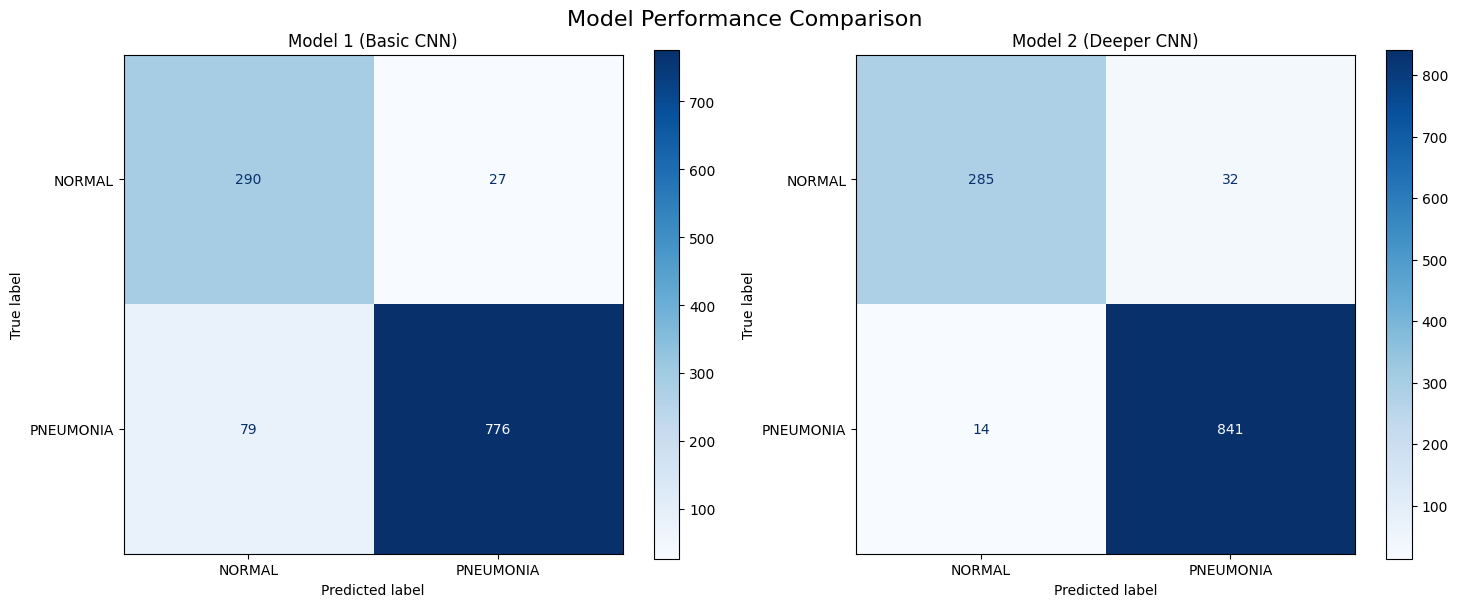

In [21]:
# --- Confusion Matrices Plot Karna ---

# FIX: Hum class names manually define karenge kyunki 'PneumoniaDataset' 
# mein .classes attribute nahi hota hai.
class_names = ['NORMAL', 'PNEUMONIA']
print(f"Class names: {class_names}") # Output: ['NORMAL', 'PNEUMONIA']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Model Performance Comparison', fontsize=16)

# Model 1
cm1 = confusion_matrix(y_true_m1, y_pred_m1)
disp1 = ConfusionMatrixDisplay(confusion_matrix=cm1, display_labels=class_names)
disp1.plot(ax=ax1, cmap='Blues')
ax1.set_title('Model 1 (Basic CNN)')

# Model 2
cm2 = confusion_matrix(y_true_m2, y_pred_m2)
disp2 = ConfusionMatrixDisplay(confusion_matrix=cm2, display_labels=class_names)
disp2.plot(ax=ax2, cmap='Blues')
ax2.set_title('Model 2 (Deeper CNN)')

plt.tight_layout()
plt.show()

## 6. Hypothesis: "Did adding depth improve performance?"

Phase 1 ke final sawaal ka jawab

In [22]:
# --- Hypothesis ka Jawab ---
f1_m1 = metrics_m1["F1-Score"]
f1_m2 = metrics_m2["F1-Score"]
diff = f1_m2 - f1_m1

print("--- Hypothesis Answer ---")
print(f"Model 1 (Basic) F1-Score:    {f1_m1:.4f}")
print(f"Model 2 (Deeper) F1-Score:   {f1_m2:.4f}")
print("---------------------------")
print(f"Difference (M2 - M1):      {diff:+.4f}")

if diff > 0.01:
    print("\nConclusion: YES. Adding depth significantly improved the F1-Score.")
elif diff > 0:
    print("\nConclusion: MARGINALLY. Adding depth provided a small performance boost.")
else:
    print("\nConclusion: NO. Adding depth did not improve performance, and may have led to overfitting.")

--- Hypothesis Answer ---
Model 1 (Basic) F1-Score:    0.9361
Model 2 (Deeper) F1-Score:   0.9734
---------------------------
Difference (M2 - M1):      +0.0373

Conclusion: YES. Adding depth significantly improved the F1-Score.
